# UAS CITRA BIOMEDIS

## Dzhahira Shafa 
## 09011382227150

In [2]:
import os
import cv2
import pandas as pd
import numpy as np
import seaborn as sns
import albumentations as A
import torch
import shutil
import random
from tqdm import tqdm
from ultralytics import YOLO


In [3]:
import torch
print("CUDA Available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    print("CUDA Version:", torch.version.cuda)

CUDA Available: True
GPU: NVIDIA GeForce RTX 3050 Laptop GPU
CUDA Version: 12.1


In [4]:
IMAGE_DIR = r"D:\Semester 7\citra biomedis\retina object\images"
LABEL_DIR = r"D:\Semester 7\citra biomedis\retina object\labels"

def load_yolo_label(label_path):
    boxes = []
    classes = []
    if not os.path.exists(label_path):
        return boxes, classes  # label kosong / tidak ada
    with open(label_path, "r") as f:
        for line in f.readlines():
            parts = line.strip().split()
            cls = int(parts[0])
            bbox = list(map(float, parts[1:]))
            classes.append(cls)
            boxes.append(bbox)
    return boxes, classes

In [5]:
# ------- MEMBACA DATASET ----------
rows = []
for img_name in sorted(os.listdir(IMAGE_DIR)):
    img_path = os.path.join(IMAGE_DIR, img_name)
    base = os.path.splitext(img_name)[0]
    label_path = os.path.join(LABEL_DIR, f"{base}.txt")
    if not os.path.exists(img_path):
        print("❌ Image tidak ditemukan:", img_path)
        continue
    img = cv2.imread(img_path)
    boxes, classes = load_yolo_label(label_path)
    row = {
        "image_name": img_name,
        "image_path": img_path,
        "label_path": label_path,
        "num_boxes": len(boxes),
        "classes": classes,
        "boxes": boxes
    }
    rows.append(row)
# Convert ke DataFrame
df = pd.DataFrame(rows)
df

,image_name,image_path,label_path,num_boxes,classes,boxes
0,03a7f4a5786f_png.rf.9b7dcb9937bc2331c8e0e71734...,D:\Semester 7\citra biomedis\retina object\ima...,D:\Semester 7\citra biomedis\retina object\lab...,15,"[2, 2, 2, 2, 2, 2, 2, 2, 0, 0, 0, 0, 0, 1, 1]","[[0.1609375, 0.61796875, 0.015625, 0.02890625]..."
1,0ada12c0e78f_png.rf.b0238627390ec6ddef84aca558...,D:\Semester 7\citra biomedis\retina object\ima...,D:\Semester 7\citra biomedis\retina object\lab...,29,"[2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, ...","[[0.48359375, 0.478125, 0.02265625, 0.0328125]..."
2,0ceb222f6629_png.rf.49c3fa94dec6cc287daa7d4d2c...,D:\Semester 7\citra biomedis\retina object\ima...,D:\Semester 7\citra biomedis\retina object\lab...,4,"[2, 2, 2, 2]","[[0.45625, 0.27109375, 0.01328125, 0.0140625],..."
3,0e0fc1d9810c_png.rf.aa617ab2b7b8e36a908d7666ee...,D:\Semester 7\citra biomedis\retina object\ima...,D:\Semester 7\citra biomedis\retina object\lab...,10,"[2, 2, 2, 2, 2, 2, 2, 3, 3, 1]","[[0.3328125, 0.3453125, 0.01171875, 0.03515625..."
4,0e82bcacc475_png.rf.e4a8c8dae592432f875aa9c3f4...,D:\Semester 7\citra biomedis\retina object\ima...,D:\Semester 7\citra biomedis\retina object\lab...,11,"[2, 2, 2, 0, 1, 1, 1, 1, 1, 1, 1]","[[0.5171875, 0.5453125, 0.01484375, 0.01640625..."
5,1a7e3356b39c_png.rf.e61b1959c1cdc2d9762bc5917b...,D:\Semester 7\citra biomedis\retina object\ima...,D:\Semester 7\citra biomedis\retina object\lab...,19,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[[0.36953125, 0.21796875, 0.178125, 0.09296875..."
6,1b32e1d775ea_png.rf.aeeaaed946c4cf15d9b5502867...,D:\Semester 7\citra biomedis\retina object\ima...,D:\Semester 7\citra biomedis\retina object\lab...,20,"[0, 0, 0, 0, 0, 0, 2, 2, 2, 1, 1, 1, 1, 1, 1, ...","[[0.3, 0.6109375, 0.0421875, 0.10625], [0.2765..."
7,1bf30c84bbad_png.rf.bd7da8ba182bffe87949178da7...,D:\Semester 7\citra biomedis\retina object\ima...,D:\Semester 7\citra biomedis\retina object\lab...,5,"[0, 0, 0, 1, 1]","[[0.6703125, 0.6703125, 0.03125, 0.059375], [0..."
8,1c4f3aa4df06_png.rf.eabab9c3e8efde6f2335b0ea35...,D:\Semester 7\citra biomedis\retina object\ima...,D:\Semester 7\citra biomedis\retina object\lab...,12,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1]","[[0.71640625, 0.62734375, 0.03203125, 0.0625],..."
9,1e9224ccca95_png.rf.713708ef855cbc0c5dabb15cb6...,D:\Semester 7\citra biomedis\retina object\ima...,D:\Semester 7\citra biomedis\retina object\lab...,19,"[0, 0, 0, 0, 0, 0, 2, 2, 2, 2, 2, 2, 1, 1, 1, ...","[[0.55546875, 0.4453125, 0.03046875, 0.1328125..."


## **AUGMENTASI**

In [6]:
AUG_IMG_DIR = r"D:\Semester 7\citra biomedis\retina object augmented\images"
AUG_LABEL_DIR = r"D:\Semester 7\citra biomedis\retina object augmented\labels"
os.makedirs(AUG_IMG_DIR, exist_ok=True)
os.makedirs(AUG_LABEL_DIR, exist_ok=True)

In [7]:
# ---- FUNGSI LOAD LABEL YOLO ----
def load_yolo_label(label_path):
    boxes = []
    classes = []

    # jika file tidak ada, kembalikan kosong
    if not os.path.exists(label_path):
        return boxes, classes

    with open(label_path, "r") as f:
        for line in f:
            parts = line.strip().split()

            # skip jika baris kosong atau tidak valid
            if len(parts) < 5:
                continue

            cls = int(parts[0])
            bbox = [float(x) for x in parts[1:]]

            classes.append(cls)
            boxes.append(bbox)

    return boxes, classes


# ---- FUNGSI SAVE LABEL YOLO ----
def save_yolo_label(save_path, classes, boxes):
    with open(save_path, "w") as f:
        for cls, box in zip(classes, boxes):
            bbox_str = " ".join(str(v) for v in box)
            f.write(f"{cls} {bbox_str}\n")

In [ ]:
# ---- Enhancement ----

transform = A.Compose(
    [
        # ---- Enhancing & Lighting ----
        A.CLAHE(clip_limit=2.0, p=0.3),                     # Kontras retina
        A.RandomBrightnessContrast(brightness_limit=0.2,
                                   contrast_limit=0.2, p=0.5),
        A.RandomGamma(gamma_limit=(80, 120), p=0.3),        

        # ---- Color Variation ----
        A.HueSaturationValue(hue_shift_limit=5,
                             sat_shift_limit=15,
                             val_shift_limit=15, p=0.3),

        # ---- Blur & Noise ----
        A.GaussianBlur(blur_limit=(3, 5), p=0.2),
        A.GaussNoise(var_limit=(5, 25), p=0.2),

        # ---- Geometric (AMAN untuk retina) ----
        A.Rotate(limit=15, p=0.4),                          # Rotasi kecil 
        A.HorizontalFlip(p=0.4),                            # Hanya horizontal
        A.ShiftScaleRotate(
            shift_limit=0.03,
            scale_limit=0.05,
            rotate_limit=0,
            border_mode=cv2.BORDER_REFLECT_101,
            p=0.3
        ),

        # ---- Distortion ringan ----
        A.ElasticTransform(
            alpha=10, sigma=10, alpha_affine=5,
            p=0.2
        ),
    ],
    bbox_params=A.BboxParams(
        format="yolo",
        label_fields=["class_labels"],
        min_visibility=0.2
    )
)


# ---- LOOP AUGMENTASI SAMPAI 100 GAMBAR ----
TARGET_TOTAL = 100
current_total = 0
aug_index = 0
image_list = sorted(os.listdir(IMAGE_DIR))
with tqdm(total=TARGET_TOTAL) as bar:
    while current_total < TARGET_TOTAL:
        for img_name in image_list:
            img_path = os.path.join(IMAGE_DIR, img_name)
            base = os.path.splitext(img_name)[0]
            label_path = os.path.join(LABEL_DIR, f"{base}.txt")
            img = cv2.imread(img_path)
            boxes, classes = load_yolo_label(label_path)
            if img is None:
                continue
            if len(boxes) == 0:
                continue
            out = transform(image=img, bboxes=boxes, class_labels=classes)
            aug_img = out["image"]
            aug_boxes = out["bboxes"]
            aug_classes = out["class_labels"]
            new_name = f"{base}_aug{aug_index}.jpg"
            new_label_name = f"{base}_aug{aug_index}.txt"
            cv2.imwrite(os.path.join(AUG_IMG_DIR, new_name), aug_img)
            save_yolo_label(os.path.join(AUG_LABEL_DIR, new_label_name), aug_classes, aug_boxes)
            current_total += 1
            aug_index += 1
            bar.update(1)
            if current_total >= TARGET_TOTAL:
                break
print("✔️ Augmentasi selesai!")
print("Total image augmented:", current_total)

C:\Users\user\AppData\Local\Temp\ipykernel_17992\3319520999.py:19: UserWarning: Argument(s) 'var_limit' are not valid for transform GaussNoise
  A.GaussNoise(var_limit=(5, 25), p=0.2),
d:\anaconda\envs\yolo\lib\site-packages\albumentations\core\validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)
C:\Users\user\AppData\Local\Temp\ipykernel_17992\3319520999.py:33: UserWarning: Argument(s) 'alpha_affine' are not valid for transform ElasticTransform
  A.ElasticTransform(
100%|██████████| 100/100 [00:03<00:00, 30.54it/s]

✔️ Augmentasi selesai!
Total image augmented: 100


## **SPLITING DATA**

In [9]:
# Folder output split
BASE_OUT = r"D:\Semester 7\citra biomedis\retina object data split"
TRAIN_IMG = os.path.join(BASE_OUT, "train/images")
TRAIN_LBL = os.path.join(BASE_OUT, "train/labels")
VAL_IMG = os.path.join(BASE_OUT, "val/images")
VAL_LBL = os.path.join(BASE_OUT, "val/labels")
TEST_IMG = os.path.join(BASE_OUT, "test/images")
TEST_LBL = os.path.join(BASE_OUT, "test/labels")

for d in [TRAIN_IMG, TRAIN_LBL, VAL_IMG, VAL_LBL, TEST_IMG, TEST_LBL]:
    os.makedirs(d, exist_ok=True)

In [10]:
# ---- GABUNGKAN FILE ORIGINAL + AUGMENT ----
all_images = []

# loop folder original + augment
for folder in [IMAGE_DIR, AUG_IMG_DIR]:
    for img in sorted(os.listdir(folder)):
        all_images.append(os.path.join(folder, img))

# acak urutan data
random.shuffle(all_images)
train_split = 0.7    
val_split   = 0.2     
test_split  = 0.1     

total = len(all_images)

train_end = int(total * train_split)
val_end   = int(total * (train_split + val_split))

train_files = all_images[:train_end]
val_files   = all_images[train_end:val_end]
test_files  = all_images[val_end:]


# ---- FUNGSI COPY DATA + LABEL ----
def copy_split(file_list, img_out, lbl_out):
    for img_path in file_list:
        img_name = os.path.basename(img_path)
        base = os.path.splitext(img_name)[0]

        # cek apakah ini hasil augmentasi
        if "aug" in img_name.lower():
            label_path = os.path.join(AUG_LABEL_DIR, f"{base}.txt")
        else:
            label_path = os.path.join(LABEL_DIR, f"{base}.txt")

        # hanya copy jika label exists
        if os.path.exists(label_path):
            shutil.copy(img_path, os.path.join(img_out, img_name))
            shutil.copy(label_path, os.path.join(lbl_out, f"{base}.txt"))


# ---- COPY SET ----
copy_split(train_files, TRAIN_IMG, TRAIN_LBL)
copy_split(val_files,   VAL_IMG, VAL_LBL)
copy_split(test_files,  TEST_IMG, TEST_LBL)


# ---- OUTPUT ----
print("✔️ Splitting selesai:")
print("Train:", len(train_files))
print("Val:", len(val_files))
print("Test:", len(test_files))


✔️ Splitting selesai:
Train: 91
Val: 25
Test: 14


## **EKSTRASI FITUR**

### YOLO BACKBONE

In [11]:
model = YOLO(r"D:\Semester 7\citra biomedis\yolo11n.pt")
backbone = torch.nn.Sequential(*model.model.model[:10])
print(backbone)

Sequential(
  (0): Conv(
    (conv): Conv2d(3, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
    (bn): BatchNorm2d(16, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
    (act): SiLU(inplace=True)
  )
  (1): Conv(
    (conv): Conv2d(16, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
    (bn): BatchNorm2d(32, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
    (act): SiLU(inplace=True)
  )
  (2): C3k2(
    (cv1): Conv(
      (conv): Conv2d(32, 32, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn): BatchNorm2d(32, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
      (act): SiLU(inplace=True)
    )
    (cv2): Conv(
      (conv): Conv2d(48, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn): BatchNorm2d(64, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
      (act): SiLU(inplace=True)
    )
    (m): ModuleList(
      (0): Bottleneck(
        (cv1): Conv(
       

In [12]:
# ---- FUNGSI EKSTRAKSI FITUR  ----
def extract_yolo_features(img_path):
    # 1. Load & preprocess
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (640, 640))          # supaya konsisten
    img_tensor = torch.from_numpy(img).permute(2, 0, 1).float()
    img_tensor = img_tensor.unsqueeze(0) / 255.0

    # 2. Ekstraksi fitur backbone
    with torch.no_grad():
        feat_map = backbone(img_tensor)

        # Pooling → membuat fitur lebih ringkas dan stabil
        pooled = torch.nn.functional.adaptive_avg_pool2d(feat_map, 1)

        # Flatten → jadi vektor 1 dimensi
        feat_vec = pooled.view(pooled.size(0), -1)

    # 3. Return ke numpy
    return feat_vec.squeeze().cpu().numpy()

### Vessel-based Feature Extractor 

In [13]:
from skimage.filters import frangi
from skimage.morphology import skeletonize
from skimage import img_as_float

def extract_vessel_features(img_path):
    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    img = cv2.resize(img, (640, 640))

    # Normalize
    img = img_as_float(img)

    # 1. Enhance vessels (Frangi filter)
    fr = frangi(img)

    # 2. Binarize vessels
    vessel_bin = (fr > 0.01).astype(np.uint8)

    # 3. Skeletonize untuk menghitung panjang vessel
    vessel_skel = skeletonize(vessel_bin).astype(np.uint8)

    # ============================
    # Feature Set
    # ============================

    vessel_density = vessel_bin.mean()
    skeleton_density = vessel_skel.mean()

    # Vessel length = jumlah pixel skeleton
    vessel_length = vessel_skel.sum()

    # Statistik Frangi
    fr_mean = fr.mean()
    fr_std = fr.std()
    fr_max = fr.max()

    return np.array([
        vessel_density,
        skeleton_density,
        vessel_length,
        fr_mean,
        fr_std,
        fr_max
    ], dtype=float)

In [14]:
TRAIN_IMG_DIR = r"D:\Semester 7\citra biomedis\retina object data split\train\images"
TRAIN_LBL_DIR = r"D:\Semester 7\citra biomedis\retina object data split\train\labels"

rows = []

for img_name in tqdm(os.listdir(TRAIN_IMG_DIR), desc="Extracting YOLO + Vessel Features"):
    img_path = os.path.join(TRAIN_IMG_DIR, img_name)
    base = os.path.splitext(img_name)[0]

    with open(os.path.join(TRAIN_LBL_DIR, base + ".txt")) as f:
        class_id = int(float(f.readline().split()[0]))

    # YOLOv11 backbone feature
    feat_yolo = extract_yolo_features(img_path)

    # Vessel features
    feat_vessel = extract_vessel_features(img_path)

    rows.append({
        "image_name": img_name,
        "class": class_id,
        "image_path": img_path,
        "yolov11_feature": feat_yolo,
        "vessel_feature": feat_vessel
    })


df_features = pd.DataFrame(rows)
df_features.head()

Extracting YOLO + Vessel Features: 100%|██████████| 91/91 [01:31<00:00,  1.01s/it]


,image_name,class,image_path,yolov11_feature,vessel_feature
0,03a7f4a5786f_png.rf.9b7dcb9937bc2331c8e0e71734...,2,D:\Semester 7\citra biomedis\retina object dat...,"[-0.20388174, 0.042409644, -0.23983076, -0.159...","[0.06817138671875, 0.0246728515625, 10106.0, 0..."
1,03a7f4a5786f_png.rf.9b7dcb9937bc2331c8e0e71734...,2,D:\Semester 7\citra biomedis\retina object dat...,"[-0.21074861, -0.04044398, -0.22841418, -0.162...","[0.04841796875, 0.02166015625, 8872.0, 0.00427..."
2,03a7f4a5786f_png.rf.9b7dcb9937bc2331c8e0e71734...,2,D:\Semester 7\citra biomedis\retina object dat...,"[-0.19551475, -0.0039494983, -0.22035126, -0.1...","[0.0431298828125, 0.0141162109375, 5782.0, 0.0..."
3,0ada12c0e78f_png.rf.b0238627390ec6ddef84aca558...,2,D:\Semester 7\citra biomedis\retina object dat...,"[-0.12342631, -0.07557102, -0.17361206, -0.127...","[0.01892822265625, 0.00930908203125, 3813.0, 0..."
4,0ada12c0e78f_png.rf.b0238627390ec6ddef84aca558...,2,D:\Semester 7\citra biomedis\retina object dat...,"[-0.10823989, -0.02152137, -0.16752434, -0.133...","[0.0209033203125, 0.00853515625, 3496.0, 0.001..."


## **MEMBUAT data.yaml**

In [15]:
import yaml

data = {
    "path": "D:/Semester 7/citra biomedis/retina object data split",
    "train": "train/images",
    "val": "val/images",
    "test": "test/images",
    "names": {
        0: "Cotton Wool",
        1: "Dot and blot hemorrhages",
        2: "Exudates",
        3: "Subhyaloid_hemorrhages"
    }
}

# Simpan YAML
with open("data.yaml", "w") as f:
    yaml.dump(data, f, default_flow_style=False, sort_keys=False)

print("data.yaml berhasil dibuat!")


data.yaml berhasil dibuat!


## **TRAINING DATA**

In [16]:
model.train(
    data=r"D:\Semester 7\citra biomedis\data.yaml",
    epochs=120,
    imgsz=640,
    batch=8,
    workers=4,
    lr0=0.001,
    optimizer="Adam",
    device=1
)


New https://pypi.org/project/ultralytics/8.3.235 available  Update with 'pip install -U ultralytics'
Ultralytics 8.3.234  Python-3.10.19 torch-2.5.1+cu121 CUDA:1 (NVIDIA GeForce RTX 3050 Laptop GPU, 4096MiB)
engine\trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=D:\Semester 7\citra biomedis\data.yaml, degrees=0.0, deterministic=True, device=1, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=120, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=D:\Semester 7\citra biomedis\yolo11n.pt, momentum=0.937, mosaic=1.0, 

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1, 2, 3])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x0000025D4938DDB0>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
       

In [17]:
metrics = model.val(save_json=True, plots=True)

Ultralytics 8.3.234  Python-3.10.19 torch-2.5.1+cu121 CUDA:0 (NVIDIA GeForce RTX 3050 Laptop GPU, 4096MiB)
YOLO11n summary (fused): 100 layers, 2,582,932 parameters, 0 gradients, 6.3 GFLOPs
val: Fast image access  (ping: 0.00.0 ms, read: 1446.01014.0 MB/s, size: 141.2 KB)
val: Scanning D:\Semester 7\citra biomedis\retina object data split\val\labels.cache... 25 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 25/25 24.4Kit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 2/2 2.0s/it 3.9s<10.2s
                   all         25        362      0.833      0.643      0.697      0.425
           Cotton Wool         13         67      0.843      0.612      0.657      0.364
Dot and blot hemorrhages         22        110      0.814      0.478      0.589       0.29
              Exudates         22        180      0.769       0.48      0.549      0.234
Subhyaloid_hemorrhages          3          5      0.907          1      0.

Folder training: D:\Semester 7\citra biomedis\runs\detect\train3


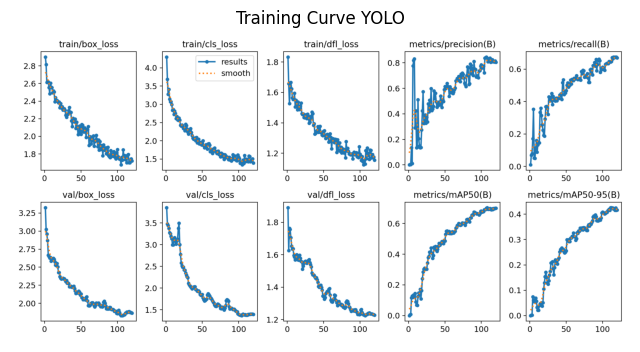

: 

In [ ]:
# Setelah training
train_dir = model.trainer.save_dir
print("Folder training:", train_dir)

curve_path = os.path.join(train_dir, "results.png")

from PIL import Image
import matplotlib.pyplot as plt

if os.path.exists(curve_path):
    img = Image.open(curve_path)
    plt.figure(figsize=(8, 8))
    plt.imshow(img)
    plt.axis("off")
    plt.title("Training Curve YOLO")
    plt.show()
else:
    print("results.png tidak ditemukan di folder training.")

In [19]:
%matplotlib inline
import matplotlib.pyplot as plt
device = 1
class_names = {
    0: "Cotton Wool",
    1: "Dot and blot hemorrhages",
    2: "Exudates",
    3: "Subhyaloid_hemorrhages"
}

def load_yolo_label(label_path):
    boxes = []
    classes = []

    if not os.path.exists(label_path):
        return boxes, classes

    with open(label_path, "r") as f:
        for line in f:
            line = line.strip()
            if line == "":
                continue  # skip baris kosong

            parts = line.split()
            if len(parts) < 5:
                continue  # skip baris invalid

            cls = int(float(parts[0]))  # aman jika "2" atau "2.0"
            bbox = list(map(float, parts[1:]))

            classes.append(cls)
            boxes.append(bbox)

    return boxes, classes


In [20]:
def inference_grid_per_class(model, image_folder, class_names, conf=0.5):
    images = [f for f in os.listdir(image_folder) if f.lower().endswith((".jpg", ".png", ".jpeg"))]

    if len(images) == 0:
        print("Tidak ada gambar di folder:", image_folder)
        return

    plt.figure(figsize=(16, 10))

    for idx, img_file in enumerate(images[:6]):  # tampilkan maksimal 6 gambar
        img_path = os.path.join(image_folder, img_file)

        results = model(img_path, conf=conf)[0]

        img = Image.open(img_path)
        img_np = np.array(img)

        plt.subplot(2, 3, idx + 1)
        plt.imshow(img_np)
        plt.axis("off")

        # Tampilkan prediksi
        for box in results.boxes:
            cls_id = int(box.cls)
            name = class_names.get(cls_id, f"Class {cls_id}")
            conf_score = float(box.conf)

            plt.title(f"{name} ({conf_score:.2f})")

    plt.tight_layout()
    plt.show()



image 1/1 D:\Semester 7\citra biomedis\retina object data split\test\images\1c4f3aa4df06_png.rf.eabab9c3e8efde6f2335b0ea359d97f2_aug8.jpg: 640x640 14 Cotton Wools, 3 Dot and blot hemorrhagess, 66.3ms
Speed: 6.2ms preprocess, 66.3ms inference, 6.5ms postprocess per image at shape (1, 3, 640, 640)

image 1/1 D:\Semester 7\citra biomedis\retina object data split\test\images\3b232b394e4f_png.rf.fc3a286fb4b12f8e8dc2b569b404dce5_aug19.jpg: 640x640 2 Subhyaloid_hemorrhagess, 64.6ms
Speed: 4.6ms preprocess, 64.6ms inference, 1.4ms postprocess per image at shape (1, 3, 640, 640)

image 1/1 D:\Semester 7\citra biomedis\retina object data split\test\images\2df07eb5779f_png.rf.862d788ef338c9f95fbd6d4cf476198e_aug13.jpg: 640x640 9 Cotton Wools, 4 Dot and blot hemorrhagess, 61.8ms
Speed: 4.5ms preprocess, 61.8ms inference, 1.8ms postprocess per image at shape (1, 3, 640, 640)

image 1/1 D:\Semester 7\citra biomedis\retina object data split\test\images\3a6e9730b298_png.rf.a427314d80a6db996e5f49ba73b

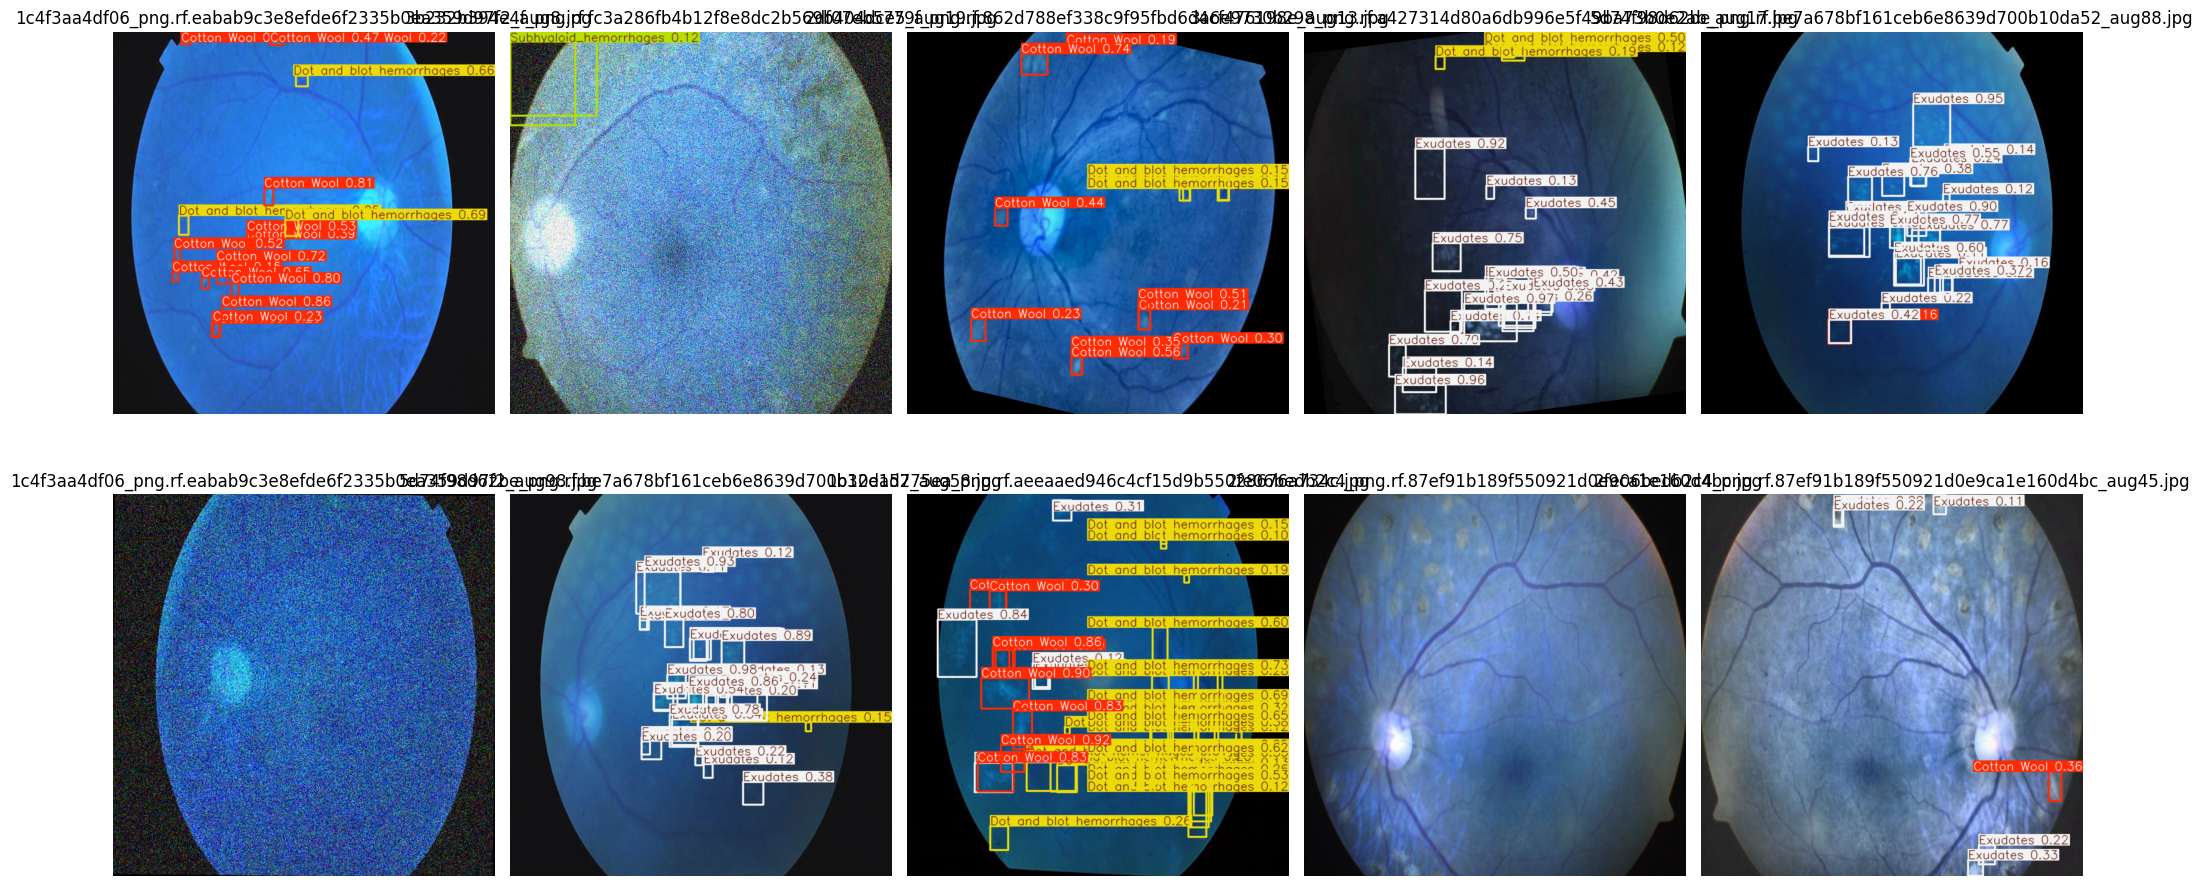

In [ ]:
import os
import random
from PIL import Image
import matplotlib.pyplot as plt

folder = r"D:\Semester 7\citra biomedis\retina object data split\test\images"

n = 10   

# Ambil semua file gambar
all_imgs = [f for f in os.listdir(folder) if f.lower().endswith((".jpg", ".jpeg", ".png"))]

# Pilih acak
random_imgs = random.sample(all_imgs, n)

# Buat grid layout
cols = 5
rows = (n + cols - 1) // cols  # otomatis berapa baris
fig, axes = plt.subplots(rows, cols, figsize=(20, 5 * rows))

# Jika hanya 1 baris, jadikan axes list
if rows == 1:
    axes = [axes]

count = 0
for row in range(rows):
    for col in range(cols):
        ax = axes[row][col] if rows > 1 else axes[col]

        if count < n:
            img_name = random_imgs[count]
            path = os.path.join(folder, img_name)

            # Deteksi
            results = model(path, conf=0.1)

            # Gambar hasil bounding box
            rendered = results[0].plot()

            ax.imshow(rendered)
            ax.set_title(img_name)
            ax.axis("off")

        else:
            ax.axis("off")

        count += 1

plt.tight_layout()
plt.show()


Folder training: D:\Semester 7\citra biomedis\runs\detect\train3


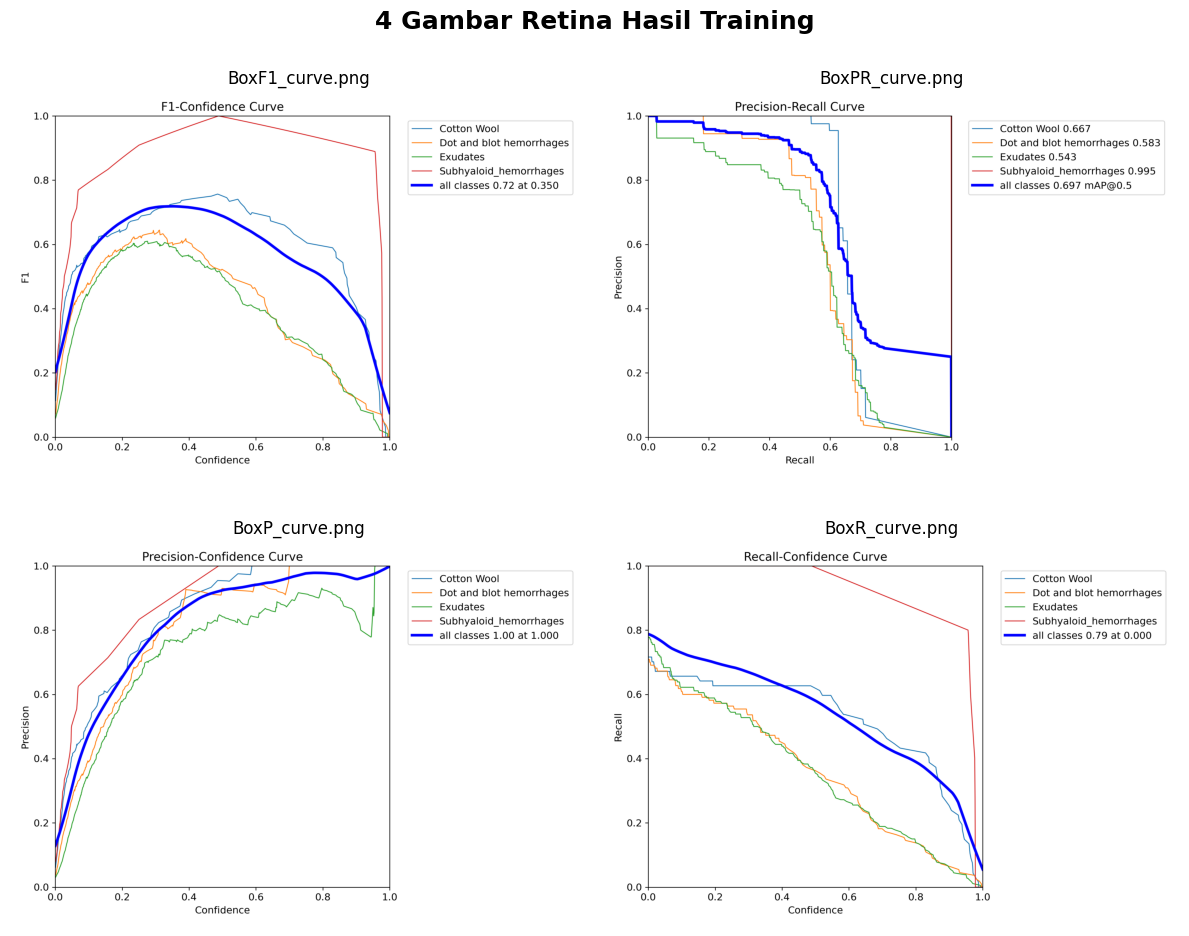

In [22]:
# Folder training terbaru
train_dir = model.trainer.save_dir
folder = train_dir

print("Folder training:", folder)

# Ambil 4 gambar retina
all_images = [f for f in os.listdir(folder) if f.lower().endswith((".png", ".jpg", ".jpeg"))]
selected_images = all_images[:4]

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
fig.suptitle("4 Gambar Retina Hasil Training", fontsize=18, fontweight='bold')

for ax, img_name in zip(axes.flatten(), selected_images):
    img_path = os.path.join(folder, img_name)
    
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    
    ax.imshow(img)
    ax.set_title(img_name)
    ax.axis("off")

plt.tight_layout()
plt.show()


Folder visualisasi: D:\Semester 7\citra biomedis\runs\detect\val


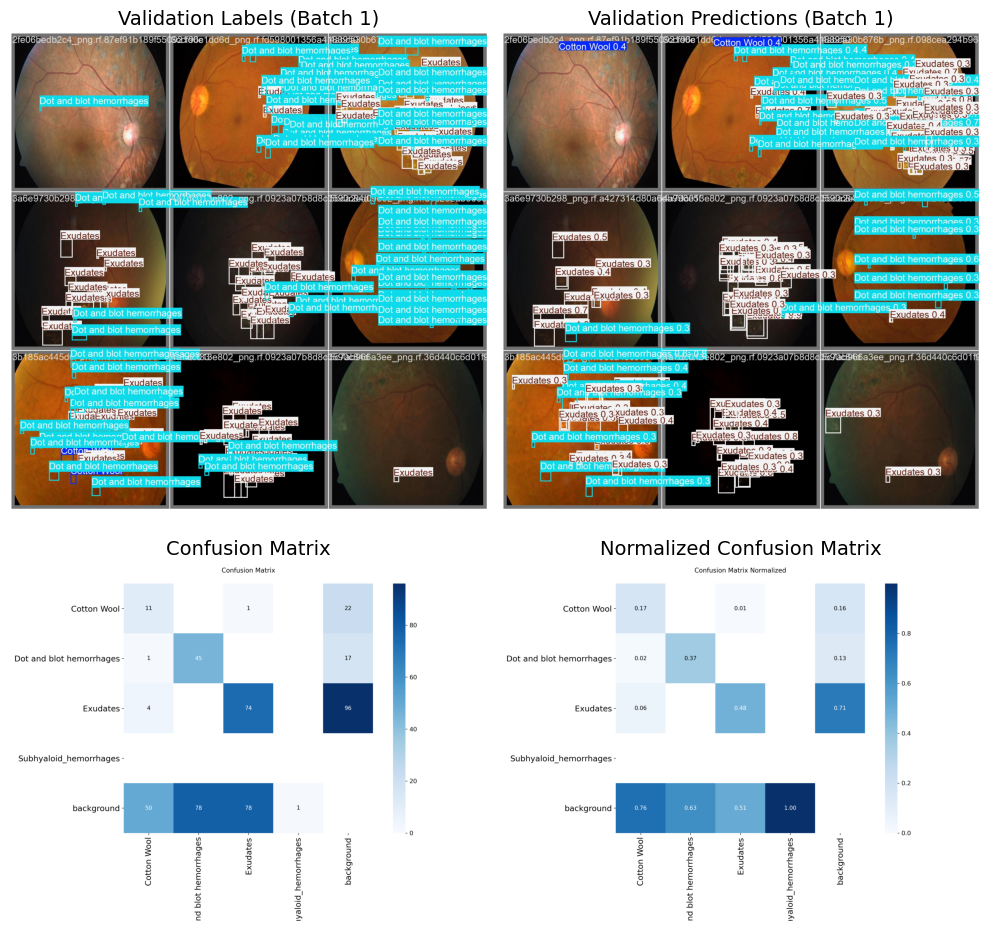

In [23]:
import os
import cv2
import matplotlib.pyplot as plt

# LANGSUNG SET FOLDER VALIDASI
val_dir = r"D:\Semester 7\citra biomedis\runs\detect\val"
print("Folder visualisasi:", val_dir)

# Daftar file yang ADA di folder kamu
file_list = {
    "Validation Labels (Batch 1)": "val_batch1_labels.jpg",
    "Validation Predictions (Batch 1)": "val_batch1_pred.jpg",
    "Confusion Matrix": "confusion_matrix.png",
    "Normalized Confusion Matrix": "confusion_matrix_normalized.png",
}

images = []
titles = []

for title, fname in file_list.items():
    full_path = os.path.join(val_dir, fname)
    
    if not os.path.exists(full_path):
        print(f"⚠️ File tidak ditemukan: {full_path}")
        continue
    
    img = cv2.imread(full_path)
    if img is None:
        print(f"⚠️ Gambar gagal dibaca: {full_path}")
        continue
    
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    images.append(img)
    titles.append(title)

# Jika tidak ada gambar sama sekali
if len(images) == 0:
    print("❌ Tidak ada gambar yang bisa ditampilkan!")
else:
    cols = 2
    rows = (len(images) + 1) // cols

    fig, axes = plt.subplots(rows, cols, figsize=(10, 5 * rows))
    axes = axes.flatten()

    for ax, img, title in zip(axes, images, titles):
        ax.imshow(img)
        ax.set_title(title, fontsize=14)
        ax.axis("off")

    # Sembunyikan axis kosong
    for ax in axes[len(images):]:
        ax.axis("off")

    plt.tight_layout()
    plt.show()
